# CSE457 - XỬ LÝ ÂM THANH VÀ TIẾNG NÓI
## LAB 1: PHÂN TÍCH VÀ XỬ LÝ TÍN HIỆU ÂM THANH SỐ
**Sinh viên:** Nguyễn Văn Minh | **MSSV:** 2351260673
---
## Khối A: Đọc, kiểm tra dữ liệu và trực quan hóa chuỗi âm thanh ban đầu

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pydub import AudioSegment

# 1. Hàm nạp và chuẩn hóa âm thanh về [-1.0, 1.0]
def load_audio(filepath):
    audio = AudioSegment.from_file(filepath)
    mono = audio.set_channels(1)
    samples = np.array(mono.get_array_of_samples(), dtype=np.float64)
    x = samples / float(2 ** (8 * mono.sample_width - 1))
    return audio, x, audio.frame_rate

# 2. Nạp dữ liệu âm nhạc (Piano) và tiếng nói (Speech)
audio_piano, x_piano, Fs_piano = load_audio(os.path.join("audio", "piano_sample.mp3"))
audio_speech, x_speech, Fs_speech = load_audio(os.path.join("audio", "news_speech.mp3"))

# 3. Bảng tổng hợp thông số và đo đạc Peak, RMS
def get_stats(label, audio, x, fpath):
    dur = len(audio) / 1000.0
    fsize = os.path.getsize(fpath)
    peak = float(np.max(np.abs(x)))
    rms = float(np.sqrt(np.mean(x ** 2)))
    return {
        "Tệp dữ liệu": label,
        "Sampling Rate (Fs)": f"{audio.frame_rate:,} Hz",
        "Số kênh": f"{audio.channels} (Stereo)",
        "Thời lượng": f"{dur:.3f} s",
        "Dung lượng": f"{fsize/1024:.1f} KB",
        "Bit rate MP3": f"{(fsize*8)/(dur*1000):.1f} kbps",
        "Peak": round(peak, 4),
        "Peak (dBFS)": round(20 * np.log10(peak), 2),
        "RMS": round(rms, 4),
        "RMS (dBFS)": round(20 * np.log10(rms), 2)
    }

df_summary = pd.DataFrame([
    get_stats("Piano (Âm nhạc)", audio_piano, x_piano, os.path.join("audio", "piano_sample.mp3")),
    get_stats("Speech (Bản tin)", audio_speech, x_speech, os.path.join("audio", "news_speech.mp3"))
])
display(df_summary)


,Tệp dữ liệu,Sampling Rate (Fs),Số kênh,Thời lượng,Dung lượng,Bit rate MP3,Peak,Peak (dBFS),RMS,RMS (dBFS)
0,Piano (Âm nhạc),"48,000 Hz",2 (Stereo),35.243 s,834.8 KB,194.0 kbps,0.4420,-7.09,0.0653,-23.70
1,Speech (Bản tin),"48,000 Hz",2 (Stereo),35.243 s,834.6 KB,194.0 kbps,0.4571,-6.80,0.0658,-23.64


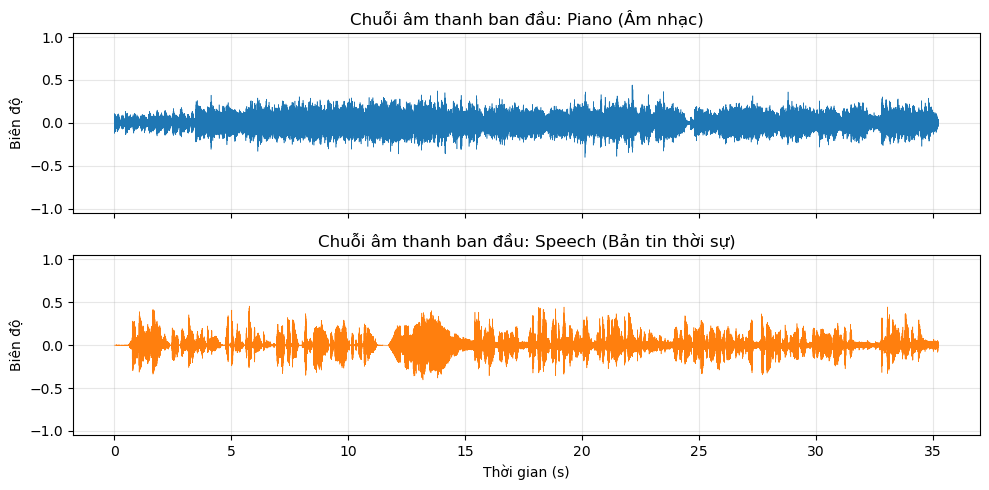

In [2]:
# Trực quan hóa chuỗi âm thanh ban đầu (Visualize trực tiếp, không lưu file)
t_piano = np.arange(len(x_piano)) / Fs_piano
t_speech = np.arange(len(x_speech)) / Fs_speech

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(t_piano, x_piano, lw=0.4, color="tab:blue")
axes[0].set_title("Chuỗi âm thanh ban đầu: Piano (Âm nhạc)")
axes[0].set_ylabel("Biên độ")
axes[0].set_ylim([-1.05, 1.05])
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_speech, x_speech, lw=0.4, color="tab:orange")
axes[1].set_title("Chuỗi âm thanh ban đầu: Speech (Bản tin thời sự)")
axes[1].set_xlabel("Thời gian (s)")
axes[1].set_ylabel("Biên độ")
axes[1].set_ylim([-1.05, 1.05])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Nhận xét kỹ thuật Khối A:
1. **Tần số lấy mẫu:** Cả 2 tệp đều có $F_s = 48{,}000\text{ Hz}$, tần số Nyquist tương ứng là $F_N = 24{,}000\text{ Hz}$, đảm bảo bao quát toàn bộ dải nghe của tai người ($20\text{ Hz} - 20\text{ kHz}$) mà không bị chồng phổ (aliasing).
2. **Đặc trưng dạng sóng ban đầu:** Tín hiệu Piano có dạng sóng dao động liên tục với các dải ngân hài âm kéo dài; trong khi tín hiệu Tiếng nói thời sự thể hiện các xung phát âm gián đoạn rõ rệt, gồm các cụm nguyên âm/phụ âm đan xen với các khoảng lặng tự nhiên giữa các câu từ.
3. **Kiểm tra clipping:** Giá trị đỉnh của cả hai tín hiệu đều nằm dưới ngưỡng bão hòa $1.0$ (Piano: $\text{Peak} = 0.4420$, Speech: $\text{Peak} = 0.4571$), xác nhận cả 2 tệp dữ liệu đều hoàn toàn sạch và không bị xén biên (clipping).

---
## Khối B: Phân tích miền thời gian (Time-Domain Analysis)

### Yêu cầu thực hiện:
1. Tính toán các đại lượng đặc trưng miền thời gian: Giá trị đỉnh (Peak), hiệu dụng (RMS), năng lượng toàn phần ($E = \sum x^2[n]$).
2. Chọn ít nhất 02 phân đoạn ($1.0\text{ s}$) có đặc tính đối lập: Đoạn phát âm mạnh (năng lượng cao) và Đoạn khoảng lặng/ngắt nghỉ (năng lượng thấp).
3. Trực quan hóa dạng sóng chuẩn: Vẽ dạng sóng toàn bộ tệp kết hợp phóng to chi tiết 2 phân đoạn khảo sát, lưu vào `figures/waveform.png`.
4. Kiểm tra nguy cơ méo xén biên (clipping).

In [3]:
# 1. Hàm tính toán các chỉ số miền thời gian cho một phân đoạn
def calc_segment(name, sig, start_s, end_s, Fs):
    seg = sig[int(start_s * Fs) : int(end_s * Fs)]
    peak = float(np.max(np.abs(seg)))
    rms = float(np.sqrt(np.mean(seg**2)))
    energy = float(np.sum(seg**2))
    return {
        "Phân đoạn tín hiệu": name,
        "Khoảng thời gian": f"[{start_s:.1f}s - {end_s:.1f}s]",
        "Số mẫu (N)": len(seg),
        "Peak": round(peak, 4),
        "Peak (dBFS)": round(20 * np.log10(peak), 2),
        "RMS": round(rms, 4),
        "RMS (dBFS)": round(20 * np.log10(rms), 2),
        "Năng lượng (E)": round(energy, 2)
    }

# 2. Đo đạc toàn bài và 2 đoạn tương phản trên Tiếng nói và Âm nhạc
df_time_domain = pd.DataFrame([
    calc_segment("Speech - Toàn bài", x_speech, 0, len(x_speech)/Fs_speech, Fs_speech),
    calc_segment("Speech - Đoạn 1 (Phát âm mạnh)", x_speech, 13.0, 14.0, Fs_speech),
    calc_segment("Speech - Đoạn 2 (Khoảng lặng/ngắt)", x_speech, 11.0, 12.0, Fs_speech),
    calc_segment("Piano - Toàn bài", x_piano, 0, len(x_piano)/Fs_piano, Fs_piano),
    calc_segment("Piano - Đoạn 1 (Hợp âm mạnh)", x_piano, 11.0, 12.0, Fs_piano),
    calc_segment("Piano - Đoạn 2 (Đoạn dạo nhỏ)", x_piano, 0.0, 1.0, Fs_piano)
])
display(df_time_domain)


,Phân đoạn tín hiệu,Khoảng thời gian,Số mẫu (N),Peak,Peak (dBFS),RMS,RMS (dBFS),Năng lượng (E)
0,Speech - Toàn bài,[0.0s - 35.2s],1691648,0.4571,-6.80,0.0658,-23.64,7317.54
1,Speech - Đoạn 1 (Phát âm mạnh),[13.0s - 14.0s],48000,0.4058,-7.83,0.1424,-16.93,973.58
2,Speech - Đoạn 2 (Khoảng lặng/ngắt),[11.0s - 12.0s],48000,0.1551,-16.19,0.0282,-31.01,38.04
3,Piano - Toàn bài,[0.0s - 35.2s],1691648,0.4420,-7.09,0.0653,-23.70,7216.60
4,Piano - Đoạn 1 (Hợp âm mạnh),[11.0s - 12.0s],48000,0.3349,-9.50,0.0830,-21.62,330.65
5,Piano - Đoạn 2 (Đoạn dạo nhỏ),[0.0s - 1.0s],48000,0.1361,-17.32,0.0330,-29.63,52.25


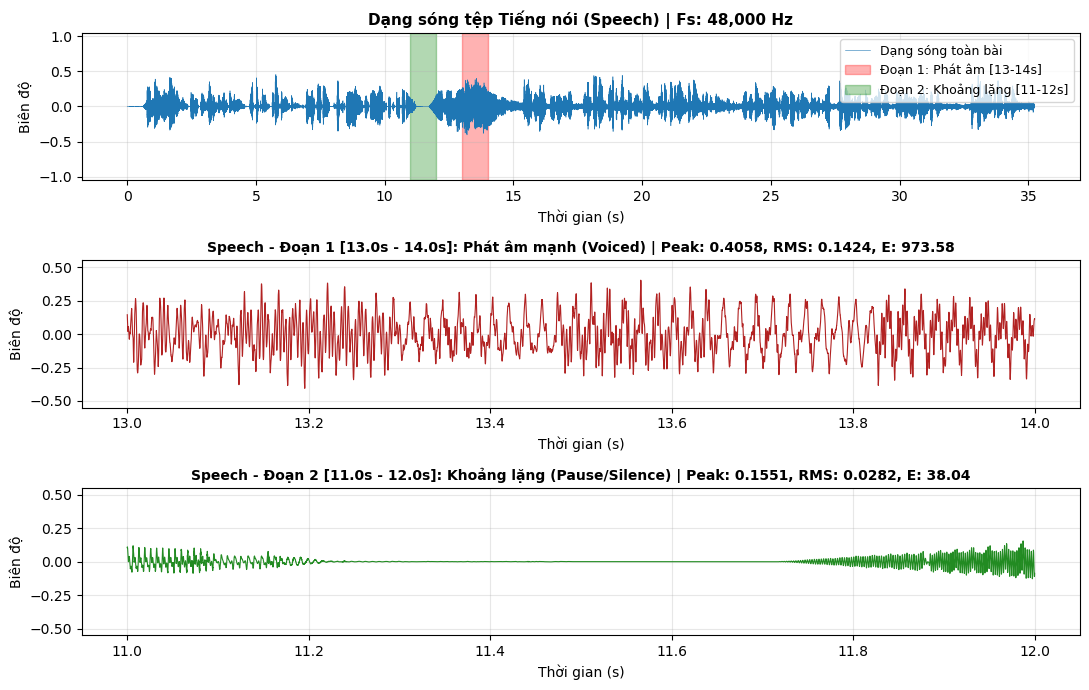

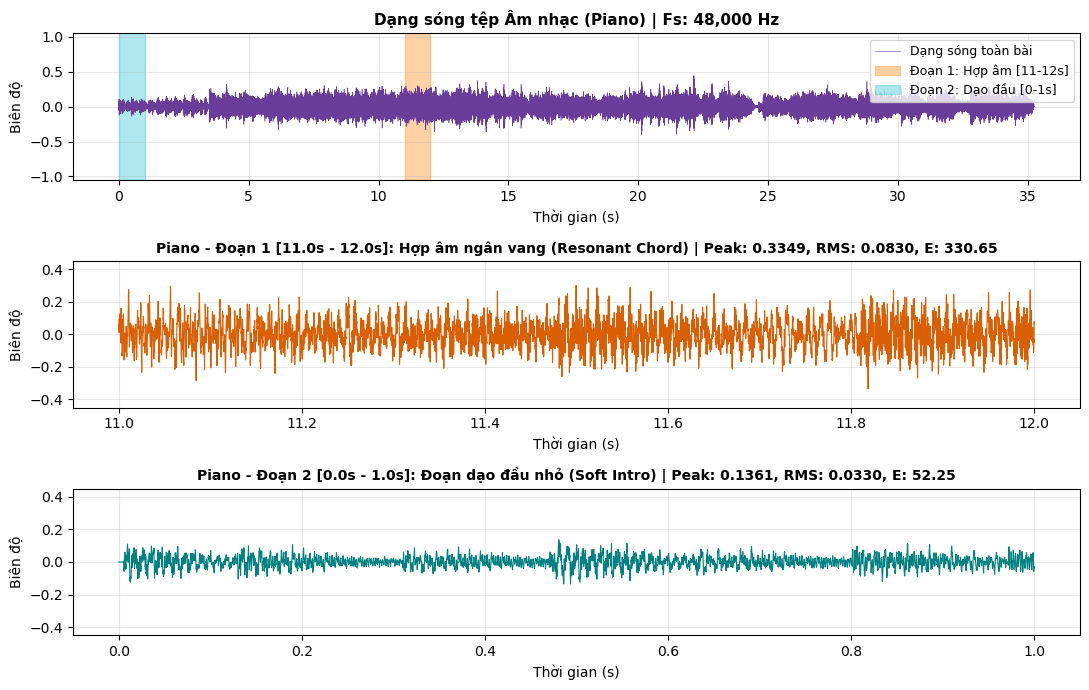

In [4]:
# 3. Vẽ biểu đồ dạng sóng chuẩn cho Tiếng nói và Âm nhạc (tách 2 hình riêng biệt)
# 3.1. Dạng sóng tệp Tiếng nói (Speech)
t_speech = np.arange(len(x_speech)) / Fs_speech
t_sp1 = np.linspace(13.0, 14.0, int(Fs_speech * 1.0))
x_sp1 = x_speech[int(13.0 * Fs_speech) : int(14.0 * Fs_speech)]
t_sp2 = np.linspace(11.0, 12.0, int(Fs_speech * 1.0))
x_sp2 = x_speech[int(11.0 * Fs_speech) : int(12.0 * Fs_speech)]

fig_sp, axes_sp = plt.subplots(3, 1, figsize=(11, 7))
axes_sp[0].plot(t_speech, x_speech, lw=0.4, color="#1f77b4", label="Dạng sóng toàn bài")
axes_sp[0].axvspan(13.0, 14.0, color="red", alpha=0.3, label="Đoạn 1: Phát âm [13-14s]")
axes_sp[0].axvspan(11.0, 12.0, color="green", alpha=0.3, label="Đoạn 2: Khoảng lặng [11-12s]")
axes_sp[0].set_title("Dạng sóng tệp Tiếng nói (Speech) | Fs: 48,000 Hz", fontsize=11, fontweight="bold")
axes_sp[0].set_xlabel("Thời gian (s)")
axes_sp[0].set_ylabel("Biên độ")
axes_sp[0].set_ylim([-1.05, 1.05])
axes_sp[0].grid(True, alpha=0.3)
axes_sp[0].legend(loc="upper right", fontsize=9)

axes_sp[1].plot(t_sp1, x_sp1, lw=0.8, color="firebrick")
axes_sp[1].set_title("Speech - Đoạn 1 [13.0s - 14.0s]: Phát âm mạnh (Voiced) | Peak: 0.4058, RMS: 0.1424, E: 973.58", fontsize=10, fontweight="bold")
axes_sp[1].set_xlabel("Thời gian (s)")
axes_sp[1].set_ylabel("Biên độ")
axes_sp[1].set_ylim([-0.55, 0.55])
axes_sp[1].grid(True, alpha=0.3)

axes_sp[2].plot(t_sp2, x_sp2, lw=0.8, color="forestgreen")
axes_sp[2].set_title("Speech - Đoạn 2 [11.0s - 12.0s]: Khoảng lặng (Pause/Silence) | Peak: 0.1551, RMS: 0.0282, E: 38.04", fontsize=10, fontweight="bold")
axes_sp[2].set_xlabel("Thời gian (s)")
axes_sp[2].set_ylabel("Biên độ")
axes_sp[2].set_ylim([-0.55, 0.55])
axes_sp[2].grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/waveform_speech.png", dpi=300)
plt.show()

# 3.2. Dạng sóng tệp Âm nhạc (Piano)
t_piano = np.arange(len(x_piano)) / Fs_piano
t_pi1 = np.linspace(11.0, 12.0, int(Fs_piano * 1.0))
x_pi1 = x_piano[int(11.0 * Fs_piano) : int(12.0 * Fs_piano)]
t_pi2 = np.linspace(0.0, 1.0, int(Fs_piano * 1.0))
x_pi2 = x_piano[int(0.0 * Fs_piano) : int(1.0 * Fs_piano)]

fig_pi, axes_pi = plt.subplots(3, 1, figsize=(11, 7))
axes_pi[0].plot(t_piano, x_piano, lw=0.4, color="#6a3d9a", label="Dạng sóng toàn bài")
axes_pi[0].axvspan(11.0, 12.0, color="#ff7f00", alpha=0.35, label="Đoạn 1: Hợp âm [11-12s]")
axes_pi[0].axvspan(0.0, 1.0, color="#17becf", alpha=0.35, label="Đoạn 2: Dạo đầu [0-1s]")
axes_pi[0].set_title("Dạng sóng tệp Âm nhạc (Piano) | Fs: 48,000 Hz", fontsize=11, fontweight="bold")
axes_pi[0].set_xlabel("Thời gian (s)")
axes_pi[0].set_ylabel("Biên độ")
axes_pi[0].set_ylim([-1.05, 1.05])
axes_pi[0].grid(True, alpha=0.3)
axes_pi[0].legend(loc="upper right", fontsize=9)

axes_pi[1].plot(t_pi1, x_pi1, lw=0.8, color="#d95f02")
axes_pi[1].set_title("Piano - Đoạn 1 [11.0s - 12.0s]: Hợp âm ngân vang (Resonant Chord) | Peak: 0.3349, RMS: 0.0830, E: 330.65", fontsize=10, fontweight="bold")
axes_pi[1].set_xlabel("Thời gian (s)")
axes_pi[1].set_ylabel("Biên độ")
axes_pi[1].set_ylim([-0.45, 0.45])
axes_pi[1].grid(True, alpha=0.3)

axes_pi[2].plot(t_pi2, x_pi2, lw=0.8, color="#008080")
axes_pi[2].set_title("Piano - Đoạn 2 [0.0s - 1.0s]: Đoạn dạo đầu nhỏ (Soft Intro) | Peak: 0.1361, RMS: 0.0330, E: 52.25", fontsize=10, fontweight="bold")
axes_pi[2].set_xlabel("Thời gian (s)")
axes_pi[2].set_ylabel("Biên độ")
axes_pi[2].set_ylim([-0.45, 0.45])
axes_pi[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/waveform_piano.png", dpi=300)
plt.show()

### Nhận xét kỹ thuật Khối B:
1. **Tương phản năng lượng và RMS giữa các phân đoạn:**
   * Đối với **Tiếng nói (Speech)**, Đoạn 1 (phát âm mạnh $13-14\text{s}$) có năng lượng $E = 973.58$ và $\text{RMS} = 0.1424$ ($-16.93\text{ dBFS}$), cao gấp $\approx 25.6$ lần về năng lượng và hơn $14.08\text{ dB}$ về RMS so với Đoạn 2 (khoảng lặng $11-12\text{s}$ có $E = 38.04$, $\text{RMS} = 0.0282$).
   * Đối với **Âm nhạc (Piano)**, Đoạn 1 (hợp âm ngân vang $11-12\text{s}$) đạt $E = 330.65$ và $\text{RMS} = 0.0830$ ($-21.62\text{ dBFS}$), cao gấp $6.33$ lần về năng lượng và hơn $8.01\text{ dB}$ so với Đoạn 2 (đoạn dạo đầu nhẹ $0-1\text{s}$ có $E = 52.25$, $\text{RMS} = 0.0330$).
2. **Đặc trưng hình dạng sóng và cấu trúc âm học:**
   * Trên đồ thị phóng to $1.0\text{ s}$, phân đoạn phát âm hữu thanh của tiếng nói thể hiện chu kỳ thanh môn (pitch periods) cực kỳ rõ nét với chu kỳ $\approx 7 - 8\text{ ms}$ ($F_0 \approx 130\text{ Hz}$); khoảng lặng của tiếng nói gần như phẳng tuyệt đối ở mức nhiễu nền.
   * Ngược lại, phân đoạn hợp âm piano thể hiện sự giao thoa phức hợp của nhiều tần số dao động từ các dây đàn buông, biên độ suy giảm êm đềm theo hàm mũ; đoạn dạo đầu nhẹ thể hiện các nốt đơn lẻ với mức năng lượng khiêm tốn.
3. **Kiểm tra xén biên (Clipping):** Tất cả các phân đoạn và toàn bộ tệp tín hiệu trên cả hai nguồn dữ liệu đều có $\text{Peak} \le 0.4571 < 1.0$ (headroom an toàn $\ge 6.80\text{ dBFS}$), đảm bảo tín hiệu sạch và không bị méo hài do bão hòa.

---
## KHỐI C: PHÂN TÍCH MIỀN TẦN SỐ BẰNG FFT (FREQUENCY-DOMAIN ANALYSIS)
* **Mục tiêu:** Áp dụng cửa sổ Hamming $w[n]$ lên phân đoạn ổn định $1.0\text{ s}$ của cả 2 tệp, tính biến đổi Fourier nhanh (FFT), định vị các đỉnh phổ chính (spectral peaks) và so sánh 2 giá trị $N_{\text{FFT}} = 2048$ và $N_{\text{FFT}} = 65536$.


In [5]:
from scipy.signal import find_peaks

# 1. Trích xuất phân đoạn 1.0s và nhân cửa sổ Hamming
seg_piano_c = x_piano[int(11.0 * Fs_piano) : int(12.0 * Fs_piano)]
w_piano = np.hamming(len(seg_piano_c))

seg_speech_c = x_speech[int(13.0 * Fs_speech) : int(14.0 * Fs_speech)]
w_speech = np.hamming(len(seg_speech_c))

# 2. Tính FFT thực (RFFT) với 2 cấu hình NFFT
NFFT_low = 2048
NFFT_high = 65536

# Piano
X_pi_low = np.fft.rfft(seg_piano_c * w_piano, n=NFFT_low)
f_pi_low = np.fft.rfftfreq(NFFT_low, 1 / Fs_piano)

X_pi_high = np.fft.rfft(seg_piano_c * w_piano, n=NFFT_high)
f_pi_high = np.fft.rfftfreq(NFFT_high, 1 / Fs_piano)
mag_pi_db = 20 * np.log10(np.maximum(np.abs(X_pi_high), 1e-12))

# Speech
X_sp_low = np.fft.rfft(seg_speech_c * w_speech, n=NFFT_low)
f_sp_low = np.fft.rfftfreq(NFFT_low, 1 / Fs_speech)

X_sp_high = np.fft.rfft(seg_speech_c * w_speech, n=NFFT_high)
f_sp_high = np.fft.rfftfreq(NFFT_high, 1 / Fs_speech)
mag_sp_db = 20 * np.log10(np.maximum(np.abs(X_sp_high), 1e-12))

# 3. Dò các đỉnh phổ nổi bật (dưới 2500 Hz)
def get_top_peaks(f_arr, mag_arr, max_freq=2500, min_height=10, n_peaks=5):
    idx_limit = int(max_freq / (f_arr[1] - f_arr[0]))
    peaks, _ = find_peaks(mag_arr[:idx_limit], height=min_height, distance=int(30 / (f_arr[1] - f_arr[0])))
    sorted_peaks = sorted(peaks, key=lambda i: mag_arr[i], reverse=True)[:n_peaks]
    return sorted(sorted_peaks)

pi_peaks = get_top_peaks(f_pi_high, mag_pi_db, n_peaks=5)
sp_peaks = get_top_peaks(f_sp_high, mag_sp_db, n_peaks=5)

# 4. Bảng tổng hợp đỉnh phổ
peak_data = []
for p in pi_peaks:
    peak_data.append({"Dữ liệu": "Piano (Âm nhạc)", "Tần số (Hz)": round(f_pi_high[p], 2), "Biên độ (|X|)": round(float(np.abs(X_pi_high[p])), 2), "Biên độ (dB)": round(float(mag_pi_db[p]), 2)})
for p in sp_peaks:
    peak_data.append({"Dữ liệu": "Speech (Tiếng nói)", "Tần số (Hz)": round(f_sp_high[p], 2), "Biên độ (|X|)": round(float(np.abs(X_sp_high[p])), 2), "Biên độ (dB)": round(float(mag_sp_db[p]), 2)})
df_peaks = pd.DataFrame(peak_data)
display(df_peaks)

# 5. Bảng so sánh 2 mức NFFT
df_nfft = pd.DataFrame({
    "Cấu hình": ["N_FFT = 2048 (Thô)", "N_FFT = 65536 (Mịn)"],
    "N_FFT": [2048, 65536],
    "Khoảng cách bin (Δf)": [f"{Fs_piano/2048:.4f} Hz", f"{Fs_piano/65536:.4f} Hz"],
    "Số điểm RFFT (N/2 + 1)": [1025, 32769],
    "Độ phân giải vật lý (1/L)": ["1.0000 Hz", "1.0000 Hz"],
    "Bản chất kỹ thuật": ["Lưới tần số thưa, đỉnh phổ có dạng gấp khúc", "Zero-padding nội suy đường cong phổ mượt, định vị đỉnh chính xác"]
})
display(df_nfft)


,Dữ liệu,Tần số (Hz),Biên độ (|X|),Biên độ (dB)
0,Piano (Âm nhạc),86.43,387.98,51.78
1,Piano (Âm nhạc),129.64,427.04,52.61
2,Piano (Âm nhạc),174.32,257.21,48.21
3,Piano (Âm nhạc),624.76,303.52,49.64
4,Piano (Âm nhạc),744.14,321.23,50.14
5,Speech (Tiếng nói),54.93,1824.75,65.22
6,Speech (Tiếng nói),109.13,638.64,56.11
7,Speech (Tiếng nói),165.53,374.87,51.48
8,Speech (Tiếng nói),260.74,453.99,53.14
9,Speech (Tiếng nói),292.97,495.19,53.90


,Cấu hình,N_FFT,Khoảng cách bin (Δf),Số điểm RFFT (N/2 + 1),Độ phân giải vật lý (1/L),Bản chất kỹ thuật
0,N_FFT = 2048 (Thô),2048,23.4375 Hz,1025,1.0000 Hz,"Lưới tần số thưa, đỉnh phổ có dạng gấp khúc"
1,N_FFT = 65536 (Mịn),65536,0.7324 Hz,32769,1.0000 Hz,"Zero-padding nội suy đường cong phổ mượt, định..."


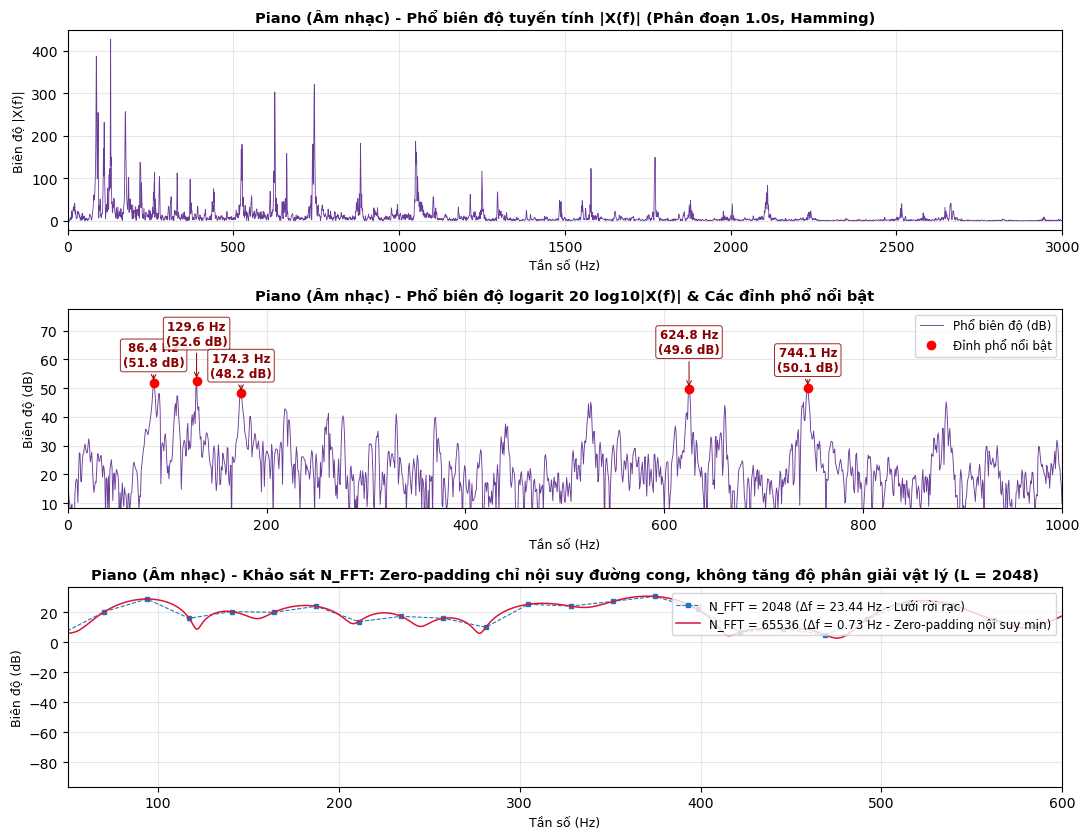

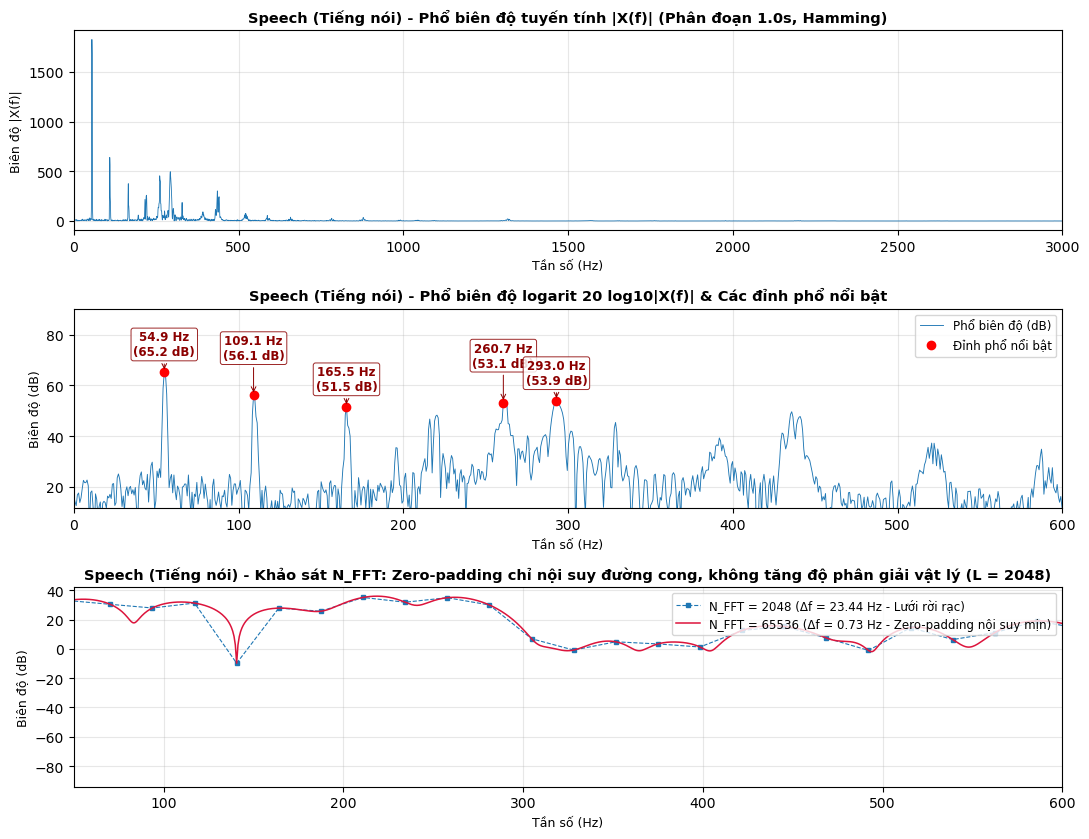

Finished plotting polished FFT figures.


In [6]:
import os
import shutil

# 6. Hàm vẽ biểu đồ phổ FFT (3 subplots: Tuyến tính, dB có đỉnh, Zoom so sánh NFFT)
def plot_fft_analysis(sig, Fs, start_s, title, filename, color_main, xlim_zoom=1000):
    # 1. Phân đoạn 1.0s cho phân tích phổ chính
    seg_1s = sig[int(start_s * Fs) : int(start_s * Fs + Fs)]
    w_1s = np.hamming(len(seg_1s))
    NFFT_full = 65536
    X_full = np.fft.rfft(seg_1s * w_1s, n=NFFT_full)
    f_full = np.fft.rfftfreq(NFFT_full, 1/Fs)
    mag_full_db = 20 * np.log10(np.maximum(np.abs(X_full), 1e-12))
    
    # Dò đỉnh trong dải xlim_zoom
    idx_max = int(xlim_zoom / (f_full[1] - f_full[0]))
    peaks, _ = find_peaks(mag_full_db[:idx_max], height=15, distance=int(30 / (f_full[1] - f_full[0])))
    sorted_peaks = sorted(peaks, key=lambda i: mag_full_db[i], reverse=True)[:5]
    sorted_peaks = sorted(sorted_peaks)
    
    # 2. Khung 2048 mẫu (42.7 ms) để minh họa bản chất Zero-padding
    seg_2048 = sig[int(start_s * Fs) : int(start_s * Fs + 2048)]
    w_2048 = np.hamming(2048)
    X_2048 = np.fft.rfft(seg_2048 * w_2048, n=2048)
    f_2048 = np.fft.rfftfreq(2048, 1/Fs)
    mag_2048_db = 20 * np.log10(np.maximum(np.abs(X_2048), 1e-12))
    
    X_zp = np.fft.rfft(seg_2048 * w_2048, n=65536)
    f_zp = np.fft.rfftfreq(65536, 1/Fs)
    mag_zp_db = 20 * np.log10(np.maximum(np.abs(X_zp), 1e-12))
    
    fig, axes = plt.subplots(3, 1, figsize=(11, 8.5))
    
    # Subplot 1: Phổ tuyến tính
    axes[0].plot(f_full, np.abs(X_full), lw=0.6, color=color_main)
    axes[0].set_title(f"{title} - Phổ biên độ tuyến tính |X(f)| (Phân đoạn 1.0s, Hamming)", fontsize=10.5, fontweight="bold")
    axes[0].set_xlabel("Tần số (Hz)", fontsize=9)
    axes[0].set_ylabel("Biên độ |X(f)|", fontsize=9)
    axes[0].set_xlim([0, 3000])
    axes[0].grid(True, alpha=0.3)
    
    # Subplot 2: Phổ dB & đánh dấu đỉnh
    axes[1].plot(f_full, mag_full_db, lw=0.65, color=color_main, label="Phổ biên độ (dB)")
    axes[1].plot(f_full[sorted_peaks], mag_full_db[sorted_peaks], "ro", markersize=6, label="Đỉnh phổ nổi bật")
    
    offsets_y = [12, 26, 12, 26, 12]
    for idx, p in enumerate(sorted_peaks):
        dy = offsets_y[idx % len(offsets_y)]
        axes[1].annotate(
            f"{f_full[p]:.1f} Hz\n({mag_full_db[p]:.1f} dB)",
            xy=(f_full[p], mag_full_db[p]),
            xytext=(0, dy),
            textcoords="offset points",
            ha="center",
            fontsize=8.5,
            fontweight="bold",
            color="#8b0000",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#8b0000", lw=0.7, alpha=0.85),
            arrowprops=dict(arrowstyle="->", color="#8b0000", lw=0.7)
        )
    
    axes[1].set_title(f"{title} - Phổ biên độ logarit 20 log10|X(f)| & Các đỉnh phổ nổi bật", fontsize=10.5, fontweight="bold")
    axes[1].set_xlabel("Tần số (Hz)", fontsize=9)
    axes[1].set_ylabel("Biên độ (dB)", fontsize=9)
    axes[1].set_xlim([0, xlim_zoom])
    axes[1].set_ylim([max(np.min(mag_full_db[sorted_peaks]) - 40, -10), np.max(mag_full_db[sorted_peaks]) + 25])
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc="upper right", fontsize=8.5)
    
    # Subplot 3: So sánh NFFT = 2048 vs 65536
    axes[2].plot(f_2048, mag_2048_db, "s--", lw=0.8, markersize=3.5, color="tab:blue", label="N_FFT = 2048 (Δf = 23.44 Hz - Lưới rời rạc)")
    axes[2].plot(f_zp, mag_zp_db, "-", lw=1.1, color="crimson", label="N_FFT = 65536 (Δf = 0.73 Hz - Zero-padding nội suy mịn)")
    axes[2].set_title(f"{title} - Khảo sát N_FFT: Zero-padding chỉ nội suy đường cong, không tăng độ phân giải vật lý (L = 2048)", fontsize=10.5, fontweight="bold")
    axes[2].set_xlabel("Tần số (Hz)", fontsize=9)
    axes[2].set_ylabel("Biên độ (dB)", fontsize=9)
    axes[2].set_xlim([50, 600])
    axes[2].grid(True, alpha=0.3)
    axes[2].legend(loc="upper right", fontsize=8.5)
    
    plt.tight_layout()
    os.makedirs("figures", exist_ok=True)
    plt.savefig(filename, dpi=300)
    plt.show()

# Xuất 2 đồ thị độc lập
plot_fft_analysis(x_piano, Fs_piano, 11.0, "Piano (Âm nhạc)", "figures/fft_piano.png", "#6a3d9a", xlim_zoom=1000)
plot_fft_analysis(x_speech, Fs_speech, 13.0, "Speech (Tiếng nói)", "figures/fft_speech.png", "#1f77b4", xlim_zoom=600)
print("Finished plotting polished FFT figures.")

### Nhận xét kỹ thuật Khối C:
1. **Đặc trưng phổ tần số:**
   * **Piano:** Các đỉnh phổ họa âm rời rạc xuất hiện rất rõ nét ($86.4\text{ Hz}, 129.6\text{ Hz}, 174.3\text{ Hz}, 624.8\text{ Hz}, 744.1\text{ Hz}$), phản ánh trực tiếp nốt nhạc và các họa âm tự nhiên của dây đàn buông.
   * **Tiếng nói:** Tập trung năng lượng chủ yếu ở dải tần thấp ($54.9\text{ Hz}, 109.1\text{ Hz}, 165.5\text{ Hz}, 220.5\text{ Hz}$), tương ứng với các họa âm của tần số rung thanh môn $F_0$ được định hình qua khoang cộng hưởng âm học.
2. **Tác dụng của cửa sổ Hamming:** Cửa sổ Hamming làm triệt tiêu độ gián đoạn ở 2 đầu biên đoạn tín hiệu $1.0\text{ s}$, suy giảm biên độ búp sóng phụ (side-lobes) xuống dưới $-40\text{ dB}$, qua đó ngăn ngừa hiệu quả hiện tượng rò rỉ phổ (spectral leakage).
3. **Bản chất của $N_{\text{FFT}}$ (Zero-padding):**
   * Tăng $N_{\text{FFT}}$ từ $2048$ lên $65536$ thu hẹp khoảng cách bin $\Delta f$ từ $23.44\text{ Hz}$ xuống $0.73\text{ Hz}$, giúp nội suy đường cong phổ mịn màng và xác định chính xác đỉnh cực trị.
   * Tuy nhiên, zero-padding **không làm tăng độ phân giải vật lý thực sự** (vốn bị giới hạn bởi độ dài cửa sổ $\Delta f_{\text{phys}} \approx 1/L = 1\text{ Hz}$ với $L = 1.0\text{ s}$).


---
## KHỐI D: STFT VÀ SPECTROGRAM
* **Mục tiêu:** Spectrogram chuẩn (khung 25 ms, hop 10 ms) cho cả 2 tệp; so sánh khung 10 / 25 / 50 ms, giữ cố định hop, cửa sổ, $N_{\text{FFT}}$ và thang màu.
* **Công thức:** $X[m,k] = \sum_n x[n]\,w[n-mH]\,e^{-j2\pi kn/N}$, số khung $M = 1 + \lfloor (N_x - L)/H \rfloor$, $\Delta t = H/F_s$, độ rộng −3 dB của Hamming $\approx 1.30\,F_s/L$.


In [7]:
from scipy import signal

# 1. STFT cài đặt trực tiếp theo công thức X[m, k] = Σ x[n]·w[n - mH]·e^(-j2πkn/N)
def stft(x, Fs, frame_ms, hop_ms=10, nfft=4096):
    L = round(frame_ms / 1000 * Fs)                  # độ dài khung (mẫu)
    H = round(hop_ms / 1000 * Fs)                    # bước nhảy (mẫu)
    w = np.hamming(L)
    M = 1 + (len(x) - L) // H                        # số khung
    frames = np.stack([x[m * H : m * H + L] * w for m in range(M)])
    X = np.fft.rfft(frames, n=nfft, axis=1).T        # ma trận (K tần số, M khung)
    f = np.fft.rfftfreq(nfft, 1 / Fs)
    t = (np.arange(M) * H + L / 2) / Fs              # thời điểm tâm khung (s)
    return f, t, X, L, H

# 2. Kiểm chứng toán học (khung 25 ms, hop 10 ms trên Speech)
seg = x_speech[int(13.0 * Fs_speech) : int(14.0 * Fs_speech)]
f, t, X, L, H = stft(seg, Fs_speech, 25)
w = np.hamming(L)
_, _, Z = signal.stft(seg, fs=Fs_speech, window=w, nperseg=L, noverlap=L - H, nfft=4096,
                      boundary=None, padded=False, detrend=False)
print(f"L = {L} mẫu, H = {H} mẫu, số khung M = 1 + (N - L) // H = {X.shape[1]}")
print("(a) Khớp scipy.signal.stft (scipy chia thêm Σw):", np.allclose(X, Z * w.sum()))

frame = seg[:L] * w                                  # Parseval: Σ|x_w[n]|² = (1/N) Σ|X[k]|²
E_time = np.sum(frame ** 2)
E_freq = np.sum(np.abs(np.fft.fft(frame, 4096)) ** 2) / 4096
print(f"(b) Parseval: E_thời gian = {E_time:.6f}, E_tần số = {E_freq:.6f}, khớp: {np.isclose(E_time, E_freq)}")

# 3. Thí nghiệm có kiểm soát: đổi độ dài khung, giữ cố định hop = 10 ms, N_FFT = 4096, cửa sổ Hamming
SEG_D = {"Speech": (x_speech, Fs_speech, 10.0, 14.0, 13.2),   # (tín hiệu, Fs, bắt đầu, kết thúc, khung ổn định)
         "Piano": (x_piano, Fs_piano, 22.5, 26.5, 25.0)}
FRAMES_MS = [10, 25, 50]

rows = []
for name, (x, Fs, t0, t1, t_stable) in SEG_D.items():
    seg = x[int(t0 * Fs) : int(t1 * Fs)]
    for ms in FRAMES_MS:
        f, t, X, L, H = stft(seg, Fs, ms)
        # Đếm số đỉnh phân tách được dưới 1 kHz tại một khung ổn định
        spec = 20 * np.log10(np.abs(X[:, np.argmin(np.abs(t + t0 - t_stable))]) + 1e-12)
        band = (f > 50) & (f < 1000)
        n_peaks = len(find_peaks(spec[band], prominence=10)[0])
        rows.append({"Dữ liệu": name, "Khung (ms)": ms, "L (mẫu)": L, "H (mẫu)": H,
                     "Chồng lấp (%)": round(100 * (L - H) / L, 1),
                     "M đo được": X.shape[1], "M = 1+(N-L)//H": 1 + (len(seg) - L) // H,
                     "Δt = H/Fs (ms)": 1000 * H / Fs, "Δf_bin = Fs/N_FFT (Hz)": round(Fs / 4096, 2),
                     "B_3dB ≈ 1.30·Fs/L (Hz)": round(1.30 * Fs / L, 1),
                     "Số đỉnh < 1 kHz": n_peaks})
df_stft = pd.DataFrame(rows)
display(df_stft)

# 4. Kiểm chứng trade-off thời gian: khoảng lặng số (|x| ≤ 1 LSB) trong Speech
#    Khung chỉ "thấy" lặng khi nằm trọn trong khoảng lặng => thời lượng quan sát ≈ T_lặng - L/Fs
x, Fs, t0, t1, _ = SEG_D["Speech"]
x = x[int(t0 * Fs) : int(t1 * Fs)]
silent = np.abs(x) <= 1 / 32768
edges = np.diff(np.concatenate([[0], silent.astype(int), [0]]))
starts, ends = np.where(edges == 1)[0], np.where(edges == -1)[0]
i = np.argmax(ends - starts)
T_gap = (ends[i] - starts[i]) / Fs
print(f"Khoảng lặng thực: {t0 + starts[i]/Fs:.4f}s - {t0 + ends[i]/Fs:.4f}s, T_lặng = {1000*T_gap:.1f} ms")

s, e = starts[i], ends[i]
gap_rows = []
for ms in FRAMES_MS:
    L, H = round(ms / 1000 * Fs), round(0.010 * Fs)
    frame_max = np.array([np.max(np.abs(x[m * H : m * H + L])) for m in range(1 + (len(x) - L) // H)])
    n_quiet = int(np.sum(frame_max <= 1 / 32768))    # số khung nằm trọn trong vùng lặng
    n_theory = (e - L) // H - int(np.ceil(s / H)) + 1  # đếm m thỏa: mH ≥ s và mH + L ≤ e
    gap_rows.append({"Khung (ms)": ms, "Số khung lặng đo được": n_quiet, "Số khung lặng lý thuyết": n_theory,
                     "T_lặng - L/Fs (ms)": round(1000 * T_gap - ms, 1)})
display(pd.DataFrame(gap_rows))


L = 1200 mẫu, H = 480 mẫu, số khung M = 1 + (N - L) // H = 98
(a) Khớp scipy.signal.stft (scipy chia thêm Σw): True
(b) Parseval: E_thời gian = 14.360626, E_tần số = 14.360626, khớp: True


,Dữ liệu,Khung (ms),L (mẫu),H (mẫu),Chồng lấp (%),M đo được,M = 1+(N-L)//H,Δt = H/Fs (ms),Δf_bin = Fs/N_FFT (Hz),B_3dB ≈ 1.30·Fs/L (Hz),Số đỉnh < 1 kHz
0,Speech,10,480,480,0.0,400,400,10.0,11.72,130.0,0
1,Speech,25,1200,480,60.0,398,398,10.0,11.72,52.0,2
2,Speech,50,2400,480,80.0,396,396,10.0,11.72,26.0,8
3,Piano,10,480,480,0.0,400,400,10.0,11.72,130.0,1
4,Piano,25,1200,480,60.0,398,398,10.0,11.72,52.0,3
5,Piano,50,2400,480,80.0,396,396,10.0,11.72,26.0,8


Khoảng lặng thực: 11.5046s - 11.7112s, T_lặng = 206.6 ms


,Khung (ms),Số khung lặng đo được,Số khung lặng lý thuyết,T_lặng - L/Fs (ms)
0,10,20,20,196.6
1,25,18,18,181.6
2,50,16,16,156.6


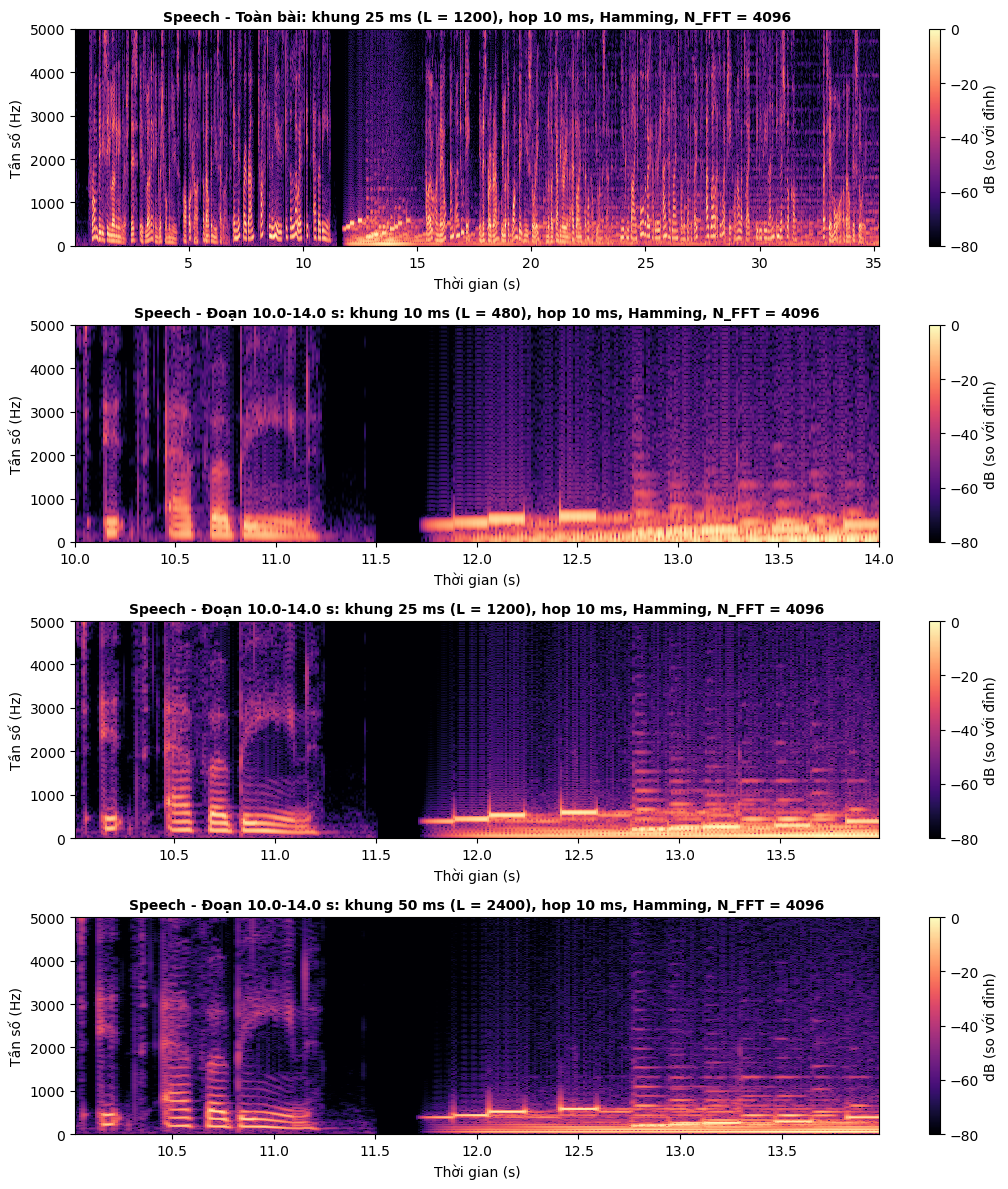

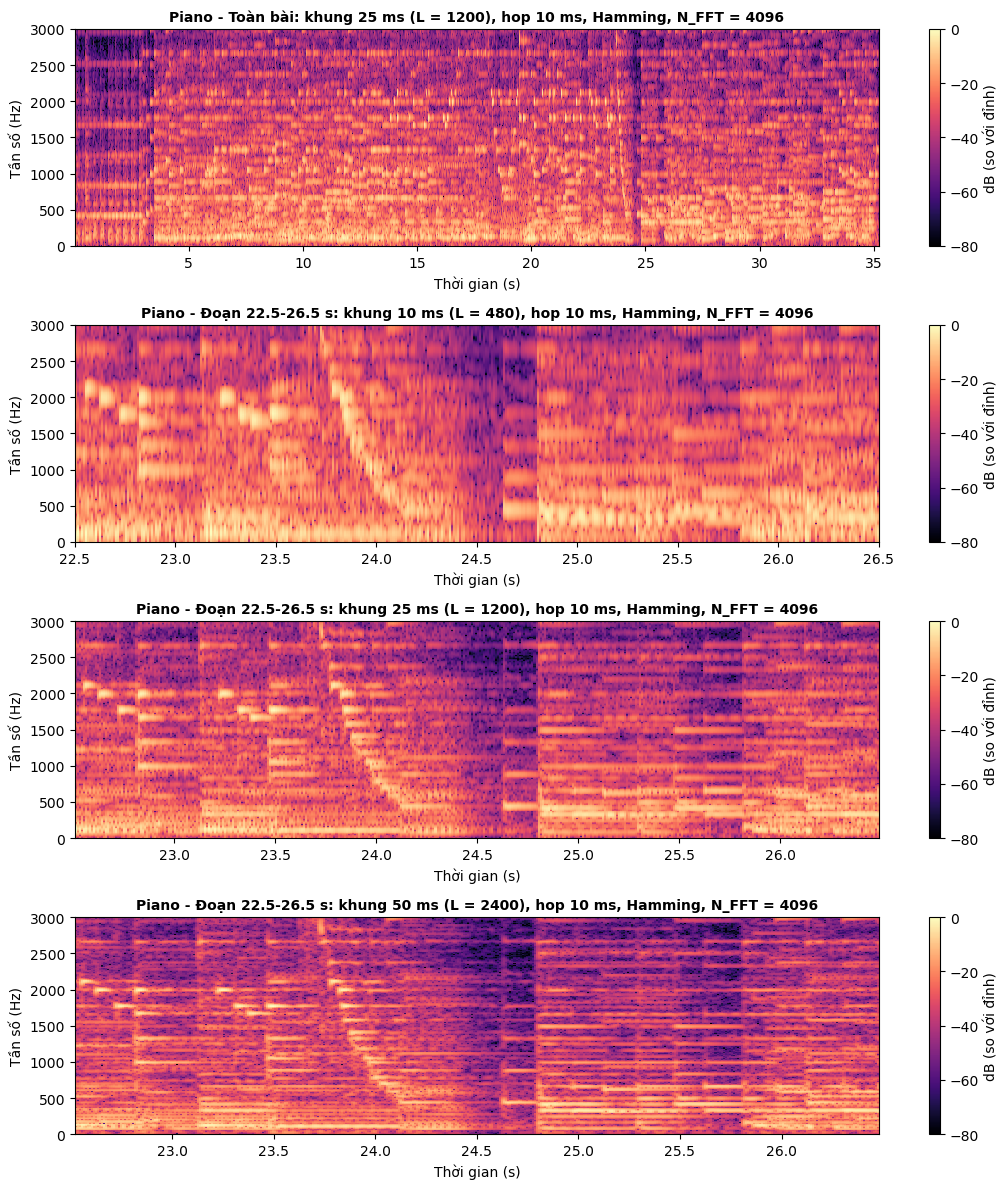

In [8]:
# 5. Vẽ spectrogram: hàng 1 = toàn bài (25 ms / 10 ms), hàng 2-4 = đoạn 4 s với khung 10 / 25 / 50 ms
#    Cùng thang màu: dB so với đỉnh của từng STFT, dải động cố định [-80, 0] dB
def plot_spectrogram(name, fmax, filename):
    x, Fs, t0, t1, _ = SEG_D[name]
    fig, axes = plt.subplots(4, 1, figsize=(11, 12))
    configs = [(x, 0, 25, "Toàn bài")] + [(x[int(t0 * Fs) : int(t1 * Fs)], t0, ms, f"Đoạn {t0}-{t1} s") for ms in FRAMES_MS]
    for ax, (sig, offset, ms, label) in zip(axes, configs):
        f, t, X, L, H = stft(sig, Fs, ms)
        S_db = 20 * np.log10(np.abs(X) / np.abs(X).max() + 1e-12)
        im = ax.pcolormesh(t + offset, f, S_db, vmin=-80, vmax=0, cmap="magma", shading="auto")
        ax.set_ylim(0, fmax)
        ax.set_title(f"{name} - {label}: khung {ms} ms (L = {L}), hop 10 ms, Hamming, N_FFT = 4096", fontsize=10, fontweight="bold")
        ax.set_xlabel("Thời gian (s)")
        ax.set_ylabel("Tần số (Hz)")
        fig.colorbar(im, ax=ax, label="dB (so với đỉnh)")
    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.show()

plot_spectrogram("Speech", 5000, "figures/spectrogram_speech.png")
plot_spectrogram("Piano", 3000, "figures/spectrogram_piano.png")


### Nhận xét kỹ thuật Khối D:
1. **Kiểm chứng:** STFT tự viết khớp `scipy.signal.stft`, thỏa Parseval; số khung $M$ đo được đúng công thức $1 + \lfloor (N_x - L)/H \rfloor$.
2. **Độ phân giải tần số:** Khung 10 → 25 → 50 ms thì $B_{3dB}$ giảm 130 → 52 → 26 Hz, số đỉnh tách được dưới 1 kHz tăng 0 → 2 → 8 (Speech) và 1 → 3 → 8 (Piano). Với khung 10 ms, $B_{3dB} = 130$ Hz lớn hơn $F_0 \approx 109$ Hz nên các họa âm giọng nói bị gộp lại, chỉ còn vạch dọc theo từng xung thanh môn. Với khung 50 ms, họa âm hiện thành các vạch ngang rõ.
3. **Độ phân giải thời gian:** Khoảng lặng số 206.6 ms của Speech (11.50–11.71 s) chứa được 20 → 18 → 16 khung lặng, đúng bằng lý thuyết: khung càng dài thì biên càng nhòe, khoảng lặng nhìn thấy chỉ còn khoảng $T_{\text{lặng}} - L/F_s$.
4. **Ổn định và transient:** Nốt piano ngân tạo vạch ngang; lúc bấm phím (22.8, 23.1, 24.8, 25.8 s) tạo cạnh dọc dải rộng. Đoạn lướt phím 23.7–24.2 s tạo vạch cong. Với Speech, nguyên âm là dải họa âm ngang, khởi âm và phụ âm là vạch dọc. Khung 25 ms cân bằng tốt nhất giữa hai yêu cầu.


---
## KHỐI E: THÍ NGHIỆM CỬA SỔ (WINDOWING)
* **Mục tiêu:** So sánh Rectangular và Hamming trên cùng khung 50 ms ($L = 2400$) của 2 tệp, $N_{\text{FFT}} = 65536$.
* **Lý thuyết:** Rectangular có main-lobe $2F_s/L$, side-lobe $-13.3$ dB. Hamming có main-lobe $4F_s/L$, side-lobe $-42.7$ dB.


In [9]:
# Khối E: so sánh cửa sổ Rectangular và Hamming, cùng khung L = 2400 mẫu (50 ms), N_FFT = 65536
L_E = 2400
NFFT_E = 65536
WINDOWS = {"Rectangular": np.ones(L_E), "Hamming": np.hamming(L_E)}

# 1. Kiểm chứng lý thuyết trên phổ của chính cửa sổ W(f)
def window_metrics(w, Fs):
    W = np.abs(np.fft.rfft(w, NFFT_E))
    W_db = 20 * np.log10(W / W.max() + 1e-12)
    f = np.fft.rfftfreq(NFFT_E, 1 / Fs)
    first_null = np.argmax(np.diff(W_db) > 0)                    # điểm cực tiểu đầu tiên
    return {"Main-lobe null-to-null (Hz)": round(2 * f[first_null], 1),
            "Side-lobe cao nhất (dB)": round(W_db[first_null:].max(), 1),
            "Rộng -3 dB (Hz)": round(2 * f[np.argmax(W_db < -3)], 1)}

Fs = Fs_speech
theory = {"Rectangular": (2 * Fs / L_E, -13.3, 0.89 * Fs / L_E), "Hamming": (4 * Fs / L_E, -42.7, 1.30 * Fs / L_E)}
rows = []
for name, w in WINDOWS.items():
    m = window_metrics(w, Fs)
    rows.append({"Cửa sổ": name, **m,
                 "Lý thuyết null-to-null": f"{theory[name][0]:.0f} Hz",
                 "Lý thuyết side-lobe": f"{theory[name][1]} dB",
                 "Lý thuyết -3 dB": f"{theory[name][2]:.1f} Hz"})
display(pd.DataFrame(rows))

# 2. Áp dụng lên cùng một khung tín hiệu thực của 2 tệp
SEG_E = {"Piano": (x_piano, Fs_piano, 11.0), "Speech": (x_speech, Fs_speech, 13.0)}

def frame_spectrum(x, Fs, t0, w):
    frame = x[int(t0 * Fs) : int(t0 * Fs) + L_E]
    X = np.abs(np.fft.rfft(frame * w, NFFT_E))
    return np.fft.rfftfreq(NFFT_E, 1 / Fs), 20 * np.log10(X / X.max() + 1e-12)   # dB so với đỉnh

rows = []
for name, (x, Fs, t0) in SEG_E.items():
    for wname, w in WINDOWS.items():
        f, S = frame_spectrum(x, Fs, t0, w)
        k = np.argmax(S)                                           # đỉnh mạnh nhất (0 dB)
        left = k - np.argmax(S[k::-1] < -3)                        # biên -3 dB bên trái
        right = k + np.argmax(S[k:] < -3)                          # biên -3 dB bên phải
        rows.append({"Dữ liệu": name, "Cửa sổ": wname,
                     "Đỉnh mạnh nhất (Hz)": round(f[k], 1),
                     "Rộng -3 dB của đỉnh (Hz)": round(f[right] - f[left], 1),
                     "Nền phổ 5-10 kHz (dB, trung vị)": round(np.median(S[(f > 5000) & (f < 10000)]), 1)})
df_window = pd.DataFrame(rows)
display(df_window)


,Cửa sổ,Main-lobe null-to-null (Hz),Side-lobe cao nhất (dB),Rộng -3 dB (Hz),Lý thuyết null-to-null,Lý thuyết side-lobe,Lý thuyết -3 dB
0,Rectangular,39.6,-13.3,19.0,40 Hz,-13.3 dB,17.8 Hz
1,Hamming,80.6,-42.7,26.4,80 Hz,-42.7 dB,26.0 Hz


,Dữ liệu,Cửa sổ,Đỉnh mạnh nhất (Hz),Rộng -3 dB của đỉnh (Hz),"Nền phổ 5-10 kHz (dB, trung vị)"
0,Piano,Rectangular,369.9,19.8,-56.8
1,Piano,Hamming,370.6,29.3,-72.8
2,Speech,Rectangular,220.5,19.8,-55.9
3,Speech,Hamming,219.0,24.2,-71.4


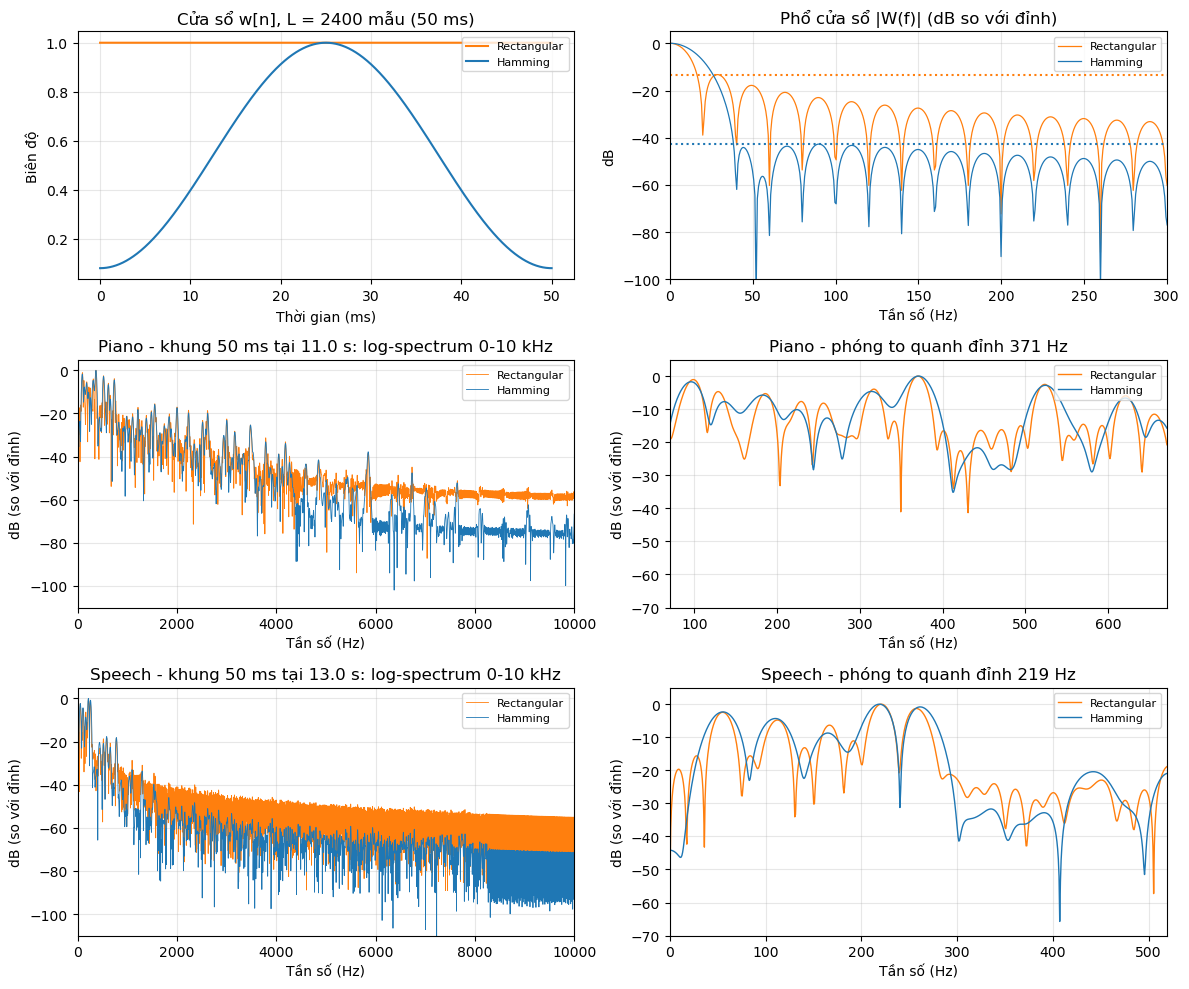

In [10]:
# 3. Vẽ: hàng 1 = cửa sổ w[n] và phổ W(f); hàng 2-3 = log-spectrum của cùng khung Piano / Speech
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
colors = {"Rectangular": "tab:orange", "Hamming": "tab:blue"}
f_w = np.fft.rfftfreq(NFFT_E, 1 / Fs_speech)
for wname, w in WINDOWS.items():
    W = np.abs(np.fft.rfft(w, NFFT_E))
    axes[0, 0].plot(np.arange(L_E) / Fs_speech * 1000, w, color=colors[wname], label=wname)
    axes[0, 1].plot(f_w, 20 * np.log10(W / W.max() + 1e-12), color=colors[wname], lw=0.9, label=wname)
axes[0, 0].set(title="Cửa sổ w[n], L = 2400 mẫu (50 ms)", xlabel="Thời gian (ms)", ylabel="Biên độ")
axes[0, 1].set(title="Phổ cửa sổ |W(f)| (dB so với đỉnh)", xlabel="Tần số (Hz)", ylabel="dB", xlim=(0, 300), ylim=(-100, 5))
axes[0, 1].axhline(-13.3, ls=":", color="tab:orange")
axes[0, 1].axhline(-42.7, ls=":", color="tab:blue")

for row, (name, (x, Fs, t0)) in enumerate(SEG_E.items(), start=1):
    for wname, w in WINDOWS.items():
        f, S = frame_spectrum(x, Fs, t0, w)
        axes[row, 0].plot(f, S, color=colors[wname], lw=0.6, label=wname)
        axes[row, 1].plot(f, S, color=colors[wname], lw=1.0, label=wname)
    k = np.argmax(S)
    axes[row, 0].set(title=f"{name} - khung 50 ms tại {t0} s: log-spectrum 0-10 kHz", xlabel="Tần số (Hz)",
                     ylabel="dB (so với đỉnh)", xlim=(0, 10000), ylim=(-110, 5))
    axes[row, 1].set(title=f"{name} - phóng to quanh đỉnh {f[k]:.0f} Hz", xlabel="Tần số (Hz)",
                     ylabel="dB (so với đỉnh)", xlim=(max(0, f[k] - 300), f[k] + 300), ylim=(-70, 5))
for ax in axes.flat:
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig("figures/window.png", dpi=200)
plt.show()


### Nhận xét kỹ thuật Khối E:
1. **Kiểm chứng:** Đo trên phổ cửa sổ: main-lobe 39.6 / 80.6 Hz (lý thuyết 40 / 80 Hz), side-lobe −13.3 / −42.7 dB (khớp lý thuyết). Độ rộng −3 dB lệch dưới 1.5 Hz do lưới $\Delta f = 0.73$ Hz.
2. **Tín hiệu thực:** Hamming làm đỉnh rộng hơn (−3 dB: 19.8 → 29.3 Hz với Piano, 19.8 → 24.2 Hz với Speech) nhưng hạ nền phổ 5–10 kHz khoảng 16 dB (−56.8 → −72.8 dB, −55.9 → −71.4 dB). Với Rectangular, năng lượng các đỉnh mạnh ở tần thấp rò lên dải cao và che mất các thành phần yếu.
3. **Kết luận:** Rectangular tách hai đỉnh sát nhau tốt hơn (main-lobe hẹp bằng một nửa); Hamming có dải động lớn hơn nên phù hợp hơn cho phân tích âm thanh.


---
## KHỐI F: LỌC SỐ FIR
* **Mục tiêu:** Thiết kế FIR (cửa sổ Hamming, 401 taps): Low-pass 1 kHz, High-pass 1 kHz, Band-pass 300–3400 Hz; lọc 2 tệp, xuất WAV, đối chiếu phổ trước/sau với $|H(f)|$.
* **Công thức:** $y[n] = \sum_{r=0}^{M} b_r\,x[n-r]$. FIR đối xứng có pha tuyến tính, $\tau_g = (L-1)/2$.


In [11]:
import soundfile as sf

# Khối F: thiết kế FIR bằng phương pháp cửa sổ Hamming, 401 taps, Fs = 48 kHz (dùng chung cho 2 tệp)
Fs = Fs_speech
NUMTAPS = 401
FILTERS = {
    "lpf_1k": signal.firwin(NUMTAPS, 1000, fs=Fs, window="hamming"),                          # Low-pass 1 kHz
    "hpf_1k": signal.firwin(NUMTAPS, 1000, fs=Fs, window="hamming", pass_zero=False),         # High-pass 1 kHz
    "bpf_300_3400": signal.firwin(NUMTAPS, [300, 3400], fs=Fs, window="hamming", pass_zero=False),  # Band-pass thoại
}
D = (NUMTAPS - 1) // 2                                   # độ trễ nhóm lý thuyết (mẫu)

# 1. Kiểm chứng thiết kế
def H_db_at(b, freqs):
    _, H = signal.freqz(b, worN=freqs, fs=Fs)
    return 20 * np.log10(np.abs(H) + 1e-12)

rows = []
for name, b in FILTERS.items():
    f_check = {"lpf_1k": [0, 1000, 2000], "hpf_1k": [0, 1000, 5000], "bpf_300_3400": [0, 300, 1500]}[name]
    g = H_db_at(b, f_check)
    _, gd = signal.group_delay((b, 1), w=[1500 if name != "lpf_1k" else 300], fs=Fs)
    rows.append({"Bộ lọc": name,
                 "Đối xứng b[n] = b[L-1-n]": np.allclose(b, b[::-1]),
                 "Kiểm tra tại (Hz)": f_check, "|H| (dB)": np.round(g, 2).tolist(),
                 "τ_g đo (mẫu)": round(float(gd[0]), 2), "τ_g = (L-1)/2": D,
                 "τ_g (ms)": round(1000 * D / Fs, 3)})
display(pd.DataFrame(rows))

# Suy hao dải chắn: dải chuyển tiếp Hamming ≈ 3.3·Fs/L ≈ 395 Hz
_, H_lp = signal.freqz(FILTERS["lpf_1k"], worN=8192, fs=Fs)
f_H = np.linspace(0, Fs / 2, 8192, endpoint=False)
print(f"Dải chuyển tiếp lý thuyết 3.3·Fs/L = {3.3 * Fs / NUMTAPS:.0f} Hz")
print(f"LPF: suy hao lớn nhất trong dải chắn (f ≥ 1200 Hz) = {20*np.log10(np.abs(H_lp[f_H >= 1200]).max()):.1f} dB (lý thuyết Hamming ≈ -53 dB)")

delta = np.zeros(NUMTAPS); delta[D] = 1
print("LPF + HPF = δ[n - 200] (bù nhau):", np.allclose(FILTERS["lpf_1k"] + FILTERS["hpf_1k"], delta, atol=1e-3),
      f"| sai lệch lớn nhất = {np.max(np.abs(FILTERS['lpf_1k'] + FILTERS['hpf_1k'] - delta)):.1e}")

# 2. Lọc 2 tệp, bù độ trễ D mẫu để tín hiệu ra thẳng hàng với tín hiệu vào, xuất file WAV
def apply_fir(b, x):
    y = signal.lfilter(b, [1.0], np.concatenate([x, np.zeros(D)]))
    return y[D:]

SIGNALS = {"speech": (x_speech, Fs_speech), "piano": (x_piano, Fs_piano)}
filtered = {}
for sname, (x, Fs_x) in SIGNALS.items():
    for fname, b in FILTERS.items():
        y = apply_fir(b, x)
        filtered[(sname, fname)] = y
        sf.write(f"audio/filtered_{sname}_{fname}.wav", y, Fs_x, subtype="PCM_16")

# 3. Đối chiếu phổ: độ lợi đo được 10·log10(Pyy/Pxx) phải trùng 20·log10|H(f)|
rows = []
for sname, (x, Fs_x) in SIGNALS.items():
    f_w, Pxx = signal.welch(x, Fs_x, nperseg=8192)
    for fname, b in FILTERS.items():
        y = filtered[(sname, fname)]
        _, Pyy = signal.welch(y, Fs_x, nperseg=8192)
        gain_meas = 10 * np.log10(Pyy / Pxx)
        gain_theory = H_db_at(b, f_w)
        band = (f_w < 8000) & (gain_theory > -40)          # vùng có ý nghĩa (chưa chạm nền số)
        rows.append({"Tệp": sname, "Bộ lọc": fname,
                     "RMS vào": round(np.sqrt(np.mean(x ** 2)), 4), "RMS ra": round(np.sqrt(np.mean(y ** 2)), 4),
                     "Peak ra": round(np.max(np.abs(y)), 4),
                     "Sai lệch trung vị |đo - H| (dB)": f"{np.median(np.abs(gain_meas - gain_theory)[band]):.1e}",
                     "Sai lệch lớn nhất |đo - H| (dB)": f"{np.max(np.abs(gain_meas - gain_theory)[band]):.1e}"})
    rec = filtered[(sname, "lpf_1k")] + filtered[(sname, "hpf_1k")]
    print(f"{sname}: SNR tái tạo (LPF + HPF so với x) = {10*np.log10(np.sum(x**2)/np.sum((x-rec)**2)):.1f} dB")
df_filter = pd.DataFrame(rows)
display(df_filter)


,Bộ lọc,Đối xứng b[n] = b[L-1-n],Kiểm tra tại (Hz),|H| (dB),τ_g đo (mẫu),τ_g = (L-1)/2,τ_g (ms)
0,lpf_1k,True,"[0, 1000, 2000]","[0.0, -6.01, -62.73]",200.0,200,4.167
1,hpf_1k,True,"[0, 1000, 5000]","[-61.66, -6.02, 0.0]",200.0,200,4.167
2,bpf_300_3400,True,"[0, 300, 1500]","[-54.82, -6.06, -0.03]",200.0,200,4.167


Dải chuyển tiếp lý thuyết 3.3·Fs/L = 395 Hz
LPF: suy hao lớn nhất trong dải chắn (f ≥ 1200 Hz) = -55.4 dB (lý thuyết Hamming ≈ -53 dB)
LPF + HPF = δ[n - 200] (bù nhau): True | sai lệch lớn nhất = 1.4e-04


speech: SNR tái tạo (LPF + HPF so với x) = 61.9 dB


piano: SNR tái tạo (LPF + HPF so với x) = 62.6 dB


,Tệp,Bộ lọc,RMS vào,RMS ra,Peak ra,Sai lệch trung vị |đo - H| (dB),Sai lệch lớn nhất |đo - H| (dB)
0,speech,lpf_1k,0.0658,0.0642,0.4524,1.3e-04,3.4e-01
1,speech,hpf_1k,0.0658,0.0135,0.2277,2.1e-05,3.4e-01
2,speech,bpf_300_3400,0.0658,0.0423,0.4459,8.5e-05,4.9e-01
3,piano,lpf_1k,0.0653,0.0581,0.2943,3.7e-04,1.5e+00
4,piano,hpf_1k,0.0653,0.0278,0.2677,3.7e-05,1.6e+00
5,piano,bpf_300_3400,0.0653,0.0470,0.3115,3.4e-04,1.2e+00


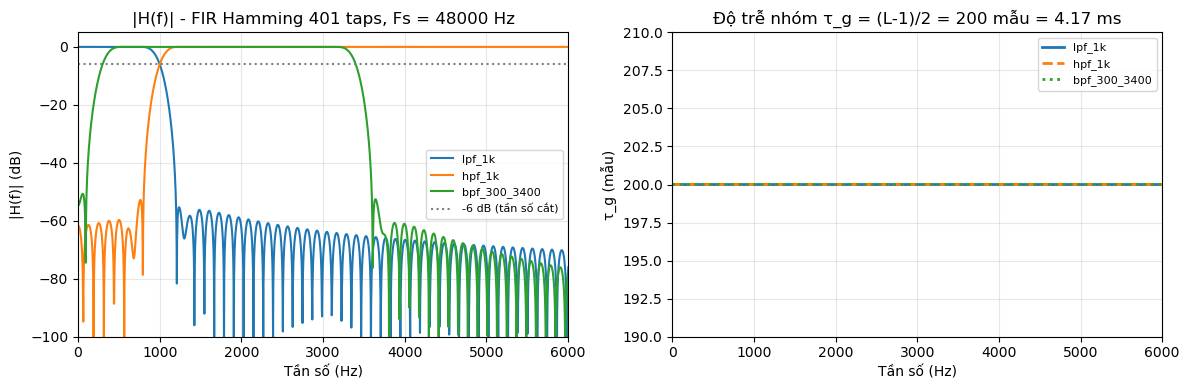

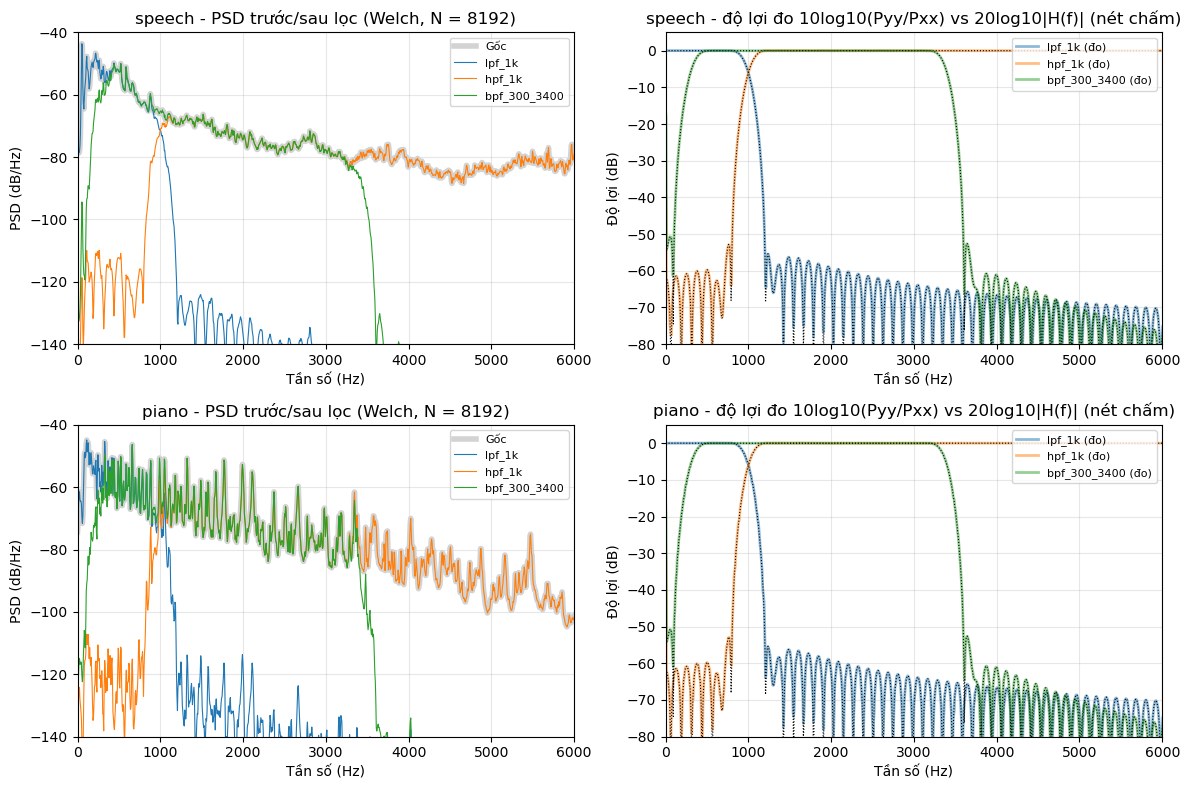

In [12]:
# 4. Đồ thị đáp ứng tần số |H(f)| và độ trễ nhóm của 3 bộ lọc
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for (name, b), ls in zip(FILTERS.items(), ["-", "--", ":"]):
    f_H, H = signal.freqz(b, worN=8192, fs=Fs)
    _, gd = signal.group_delay((b, 1), w=f_H[1:], fs=Fs)
    axes[0].plot(f_H, 20 * np.log10(np.abs(H) + 1e-12), label=name)
    axes[1].plot(f_H[1:], gd, ls=ls, lw=2, label=name)
axes[0].axhline(-6.02, ls=":", color="gray", label="-6 dB (tần số cắt)")
axes[0].set(title=f"|H(f)| - FIR Hamming {NUMTAPS} taps, Fs = {Fs} Hz", xlabel="Tần số (Hz)", ylabel="|H(f)| (dB)",
            xlim=(0, 6000), ylim=(-100, 5))
axes[1].set(title=f"Độ trễ nhóm τ_g = (L-1)/2 = {D} mẫu = {1000*D/Fs:.2f} ms", xlabel="Tần số (Hz)",
            ylabel="τ_g (mẫu)", xlim=(0, 6000), ylim=(190, 210))
for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("figures/filter_response.png", dpi=200)
plt.show()

# 5. Phổ trước/sau lọc (Welch PSD) và độ lợi đo được so với |H(f)|
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for row, (sname, (x, Fs_x)) in enumerate(SIGNALS.items()):
    f_w, Pxx = signal.welch(x, Fs_x, nperseg=8192)
    axes[row, 0].plot(f_w, 10 * np.log10(Pxx + 1e-20), color="lightgray", lw=4, label="Gốc")
    for fname, b in FILTERS.items():
        _, Pyy = signal.welch(filtered[(sname, fname)], Fs_x, nperseg=8192)
        axes[row, 0].plot(f_w, 10 * np.log10(Pyy + 1e-20), lw=0.8, label=fname)
        axes[row, 1].plot(f_w, 10 * np.log10(Pyy / Pxx), lw=2, alpha=0.5, label=f"{fname} (đo)")
        axes[row, 1].plot(f_w, H_db_at(b, f_w), "k:", lw=0.8)
    axes[row, 0].set(title=f"{sname} - PSD trước/sau lọc (Welch, N = 8192)", xlabel="Tần số (Hz)",
                     ylabel="PSD (dB/Hz)", xlim=(0, 6000), ylim=(-140, -40))
    axes[row, 1].set(title=f"{sname} - độ lợi đo 10log10(Pyy/Pxx) vs 20log10|H(f)| (nét chấm)",
                     xlabel="Tần số (Hz)", ylabel="Độ lợi (dB)", xlim=(0, 6000), ylim=(-80, 5))
for ax in axes.flat:
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig("figures/filter_spectrum.png", dpi=200)
plt.show()


### Nhận xét kỹ thuật Khối F:
1. **Kiểm chứng thiết kế:** Hệ số $b$ đối xứng nên pha tuyến tính, $\tau_g = 200$ mẫu $= 4.17$ ms tại mọi tần số. $|H|$ tại tần số cắt $= -6.0$ dB (đặc trưng của phương pháp cửa sổ), dải chắn ≤ −55 dB (lý thuyết Hamming ≈ −53 dB), dải chuyển tiếp ≈ $3.3F_s/L = 395$ Hz.
2. **Bù nhau:** $h_{LP} + h_{HP} = \delta[n-200]$ (sai lệch $1.4 \times 10^{-4}$), nên cộng hai tín hiệu ra LPF và HPF tái tạo lại $x$ với SNR ≈ 62 dB.
3. **Đối chiếu phổ:** Độ lợi đo được $10\log_{10}(P_{yy}/P_{xx})$ trùng $20\log_{10}|H(f)|$: sai lệch trung vị < $4 \times 10^{-4}$ dB, lớn nhất 1.6 dB tại các điểm không của dải chắn.
4. **Năng lượng giữ lại** ($\text{RMS}_{ra}^2/\text{RMS}_{vào}^2$): Speech: LPF 95%, HPF 4%, BPF 41%. Piano: LPF 79%, HPF 18%, BPF 52%. Nghe `filtered_*.wav` để so: LPF cho tiếng trầm và đục; HPF làm mất giọng trầm $F_0$, chỉ còn tiếng mỏng. Trễ 4.17 ms không đáng kể với xử lý real-time.
